In [138]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from pybamm import exp
from pybamm import tanh

Defining Model Variables

In [139]:

xi = pybamm.SpatialVariable(
    "xi", domain="SEI layer", coord_sys="cartesian")

CL_atom = pybamm.Variable(
    "concentration of netutral lithium atoms in the SEI [mol.m-3]",  domain="SEI layer")
CL_ion = pybamm.Variable(
    "concentration of llithium ions in the SEI [mol.m-3]",  domain="SEI layer")
Phi_SEI = pybamm.Variable("Potential in the SEI [V]",  domain="SEI layer")
L_SEI = pybamm.Variable("Thickness of SEI [m]")

In [140]:
model = pybamm.lithium_ion.BaseModel()

Defining parameters of the model

In [141]:
T = pybamm.Parameter('Initial temperature [K]')
R = pybamm.Parameter('Ideal gas constant [J.K-1.mol-1]')
F = pybamm.Parameter("Faraday constant [C.mol-1]")
D_Li_atom = pybamm.Parameter(
    'diffusion coefficient of netutral lithium atoms in the SEI [m2.s-1]')
D_Li_ion = pybamm.Parameter(
    'diffusion coefficient of llithium ions in the SEI [m2.s-1]')

CL_atom_0 = pybamm.Parameter(
    "initial concentration of netutral lithium atoms in the SEI [mol.m-3]")
CL_ion_0 = pybamm.Parameter(
    "initial concentration of llithium ions in the SEI [mol.m-3]")

Phi_SEI_0 = pybamm.Parameter("initial potential in the SEI [V]")


M_SEI = pybamm.Parameter("molar weight of SEI material [kg.mol-1]")
rho_SEI = pybamm.Parameter("density of SEI material [kg.m-3]")
n_SEI = pybamm.Parameter("electrone number [-]")


L_tun = pybamm.Parameter("length of the tunneling [m]")
L_SEI_0 = pybamm.Parameter("initial thickness of SEI [m]")

CL_ion_max = pybamm.Parameter(
    "Maximum concentration in negative electrode [mol.m-3]")

CL_ion_e = pybamm.Parameter(
    "concentration of llithium ions in the electrolyte [mol.m-3]")

# j0_0 = pybamm.Parameter("Negative electrode exchange-current density [A.m-2]")

J_total = pybamm.Parameter("Total current density [A.m-2]")

j_sei_0 = pybamm.Parameter("SEI reaction exchange current density [A.m-2]")


def j0_0(ce, cs, cs_max, T):
    return pybamm.FunctionParameter(
        "Negative electrode exchange-current density [A.m-2]",
        {"concentration of llithium ions in the electrolyte [mol.m-3]": ce, "concentration of llithium ions in the SEI [mol.m-3]": cs,
            "Maximum concentration in negative electrode [mol.m-3]": cs_max, "Temperature [K]": T},
    )


def Un(x):
    return pybamm.FunctionParameter(
        "Negative electrode OCP [V]",
        {"Negative particle stoichiometry": x},
    )

In [142]:
def OCP_n(sto):
    stretch = 1.00
    # sto = stretch * cc / c_n_max
    u_eq = (
        1.9793 * exp(-39.3631 * sto)
        + 0.2482
        - 0.0909 * tanh(29.8538 * (sto - 0.1234))
        - 0.04478 * tanh(14.9159 * (sto - 0.2769))
        - 0.0205 * tanh(30.4444 * (sto - 0.6103))
    )
    return u_eq


# def OCP_n(sto):
#     return ((1.24-sto)/1.16)**2.92


def j0_0_exchange(
    c_e, c_s_surf, c_s_max, T
):
    """
    Exchange-current density for Butler-Volmer reactions between graphite and LiPF6 in
    EC:DMC.

    References
    ----------
    .. [1] Chang-Hui Chen, Ferran Brosa Planella, Kieran O’Regan, Dominika Gastol, W.
    Dhammika Widanage, and Emma Kendrick. "Development of Experimental Techniques for
    Parameterization of Multi-scale Lithium-ion Battery Models." Journal of the
    Electrochemical Society 167 (2020): 080534.

    Parameters
    ----------
    c_e : :class:`pybamm.Symbol`
        Electrolyte concentration [mol.m-3]
    c_s_surf : :class:`pybamm.Symbol`
        Particle concentration [mol.m-3]
    c_s_max : :class:`pybamm.Symbol`
        Maximum particle concentration [mol.m-3]
    T : :class:`pybamm.Symbol`
        Temperature [K]

    Returns
    -------
    :class:`pybamm.Symbol`
        Exchange-current density [A.m-2]
    """
    m_ref = 6.48e-7  # (A/m2)(m3/mol)**1.5 - includes ref concentrations
    E_r = 35000
    arrhenius = np.exp(E_r / 8.314462618 * (1 / 298.15 - 1 / T))

    return (
        # m_ref * arrhenius * c_e**0.5 *
        # c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5
        0.003
    )

In [143]:
param = pybamm.ParameterValues(
    {
        'Initial temperature [K]': 298.15,
        'Ideal gas constant [J.K-1.mol-1]': 8.314462618,
        "Faraday constant [C.mol-1]": 96485.33212,
        'diffusion coefficient of netutral lithium atoms in the SEI [m2.s-1]': 1e-18,
        'diffusion coefficient of llithium ions in the SEI [m2.s-1]': 1e-13,
        'initial concentration of netutral lithium atoms in the SEI [mol.m-3]': 1000,
        'initial concentration of llithium ions in the SEI [mol.m-3]': 1000,
        'initial potential in the SEI [V]': 2.5,
        'molar weight of SEI material [kg.mol-1]': 0.162,
        'density of SEI material [kg.m-3]': 1690,
        'electrone number [-]': 1,
        'length of the tunneling [m]': 2e-12,
        'initial thickness of SEI [m]': 1e-6,
        'Maximum concentration in negative electrode [mol.m-3]': 33000,
        "Negative electrode exchange-current density [A.m-2]":  j0_0_exchange,
        "Total current density [A.m-2]": -2.45,
        "SEI reaction exchange current density [A.m-2]": 1.5e-03,  # Kolzenberg
        "Negative electrode OCP [V]": OCP_n,
        "concentration of llithium ions in the electrolyte [mol.m-3]": 1000,


    }
)

In [144]:
NL_ions = - D_Li_ion / L_SEI * pybamm.grad(CL_ion)
# - D_Li_ion * F/(  R*T * L_SEI)*pybamm.grad(Phi_SEI)  # define the flux for lithoum ions
# define the flux for netutral lithium atoms
NL_atom = D_Li_atom / L_SEI * \
    pybamm.grad(CL_atom) - D_Li_atom * F/(R*T * L_SEI) * \
    CL_atom*pybamm.grad(Phi_SEI)*0


V_SEI = M_SEI/(n_SEI*rho_SEI)

# Unclear how to define the source terms
A = 1
R_CLi_ions = 0.0
R_CLi_atom = 0.0


# J_Li_0 = NL_atom - D_Li_atom*F/(R*T * L_SEI)*CL_atom*pybamm.grad(Phi_SEI)
# J_tun = A * J_Li_0 * pybamm.exp(- L_SEI / L_tun)
# Je = J_Li_0 + J_tun
eta_sei = Phi_SEI - Un(CL_ion/CL_ion_max)
alpha = 0.5
J_sei = - j_sei_0 * pybamm.exp(-alpha*F/(R*T)*eta_sei)
# define the rhs equation
dL_SEI_dt = -V_SEI / F * pybamm.BoundaryValue(J_sei, "right")
dCL_ion_dt = -V_SEI / (F * L_SEI) * pybamm.BoundaryValue(J_sei, "right") * pybamm.inner(
    xi, pybamm.grad(CL_ion)) - 1 / L_SEI * pybamm.div(NL_ions) + R_CLi_ions
dCL_atom_dt = - V_SEI / (F * L_SEI) * pybamm.BoundaryValue(J_sei, "right") * pybamm.inner(
    xi, pybamm.grad(CL_atom)) - 1 / L_SEI * pybamm.div(NL_atom) + R_CLi_atom

In [145]:

eta_int = Phi_SEI - Un(CL_ion/CL_ion_max)
# Prescribed current density
J_int = j0_0(CL_ion_e, pybamm.BoundaryValue(CL_ion, "left"), CL_ion_max, T) * \
    pybamm.sinh(alpha * F/(R*T) * eta_int)
model.algebraic = {Phi_SEI: J_total - (J_int+J_sei)}
model.rhs = {CL_ion: dCL_ion_dt, CL_atom: dCL_atom_dt, L_SEI: dL_SEI_dt}

In [146]:
model.variables = {
    "concentration of llithium ions in the SEI [mol.m-3]": CL_ion,
    "concentration of netutral lithium atoms in the SEI [mol.m-3]": CL_atom,
    "Potential in the SEI [V]": Phi_SEI,
    "Thickness of SEI [m]": L_SEI,
    "J_sei": J_sei,
    "J_int": J_int,
    "j0_0": j0_0(CL_ion_e, CL_ion, CL_ion_max, T),
}

In [147]:
model.initial_conditions = {CL_ion: CL_ion_0,
                            Phi_SEI: Phi_SEI_0, L_SEI: L_SEI_0, CL_atom: CL_atom_0}

lbc_CL_ion = L_SEI * pybamm.BoundaryValue(J_int, "left")/(F*D_Li_ion)
rbc_CL_ion = CL_ion_e

lbc_CL_atom = CL_atom_0
rbc_CL_atom = - L_SEI * pybamm.BoundaryValue(J_sei, "right")/(F*D_Li_atom)
# rbc_CL_atom = 0


lbc_phi_SEI = 0
rbc_phi_SEI = - Un(pybamm.BoundaryValue(CL_ion, "left") / CL_ion_max)

model.boundary_conditions = {
    CL_ion: {"left": (lbc_CL_ion, "Neumann"), "right": (rbc_CL_ion, "Dirichlet")},
    CL_atom: {"left": (lbc_CL_atom, "Dirichlet"),
              "right": (rbc_CL_atom, "Neumann")},
    Phi_SEI: {"left": (lbc_phi_SEI, "Dirichlet"),
              "right": (rbc_phi_SEI, "Dirichlet")},
}

In [148]:

geometry = pybamm.Geometry(
    {"SEI layer": {xi: {"min": pybamm.Scalar(0), "max": pybamm.Scalar(1)}}})

In [149]:
param.process_model(model)
param.process_geometry(geometry)
submesh_types = {"SEI layer": pybamm.Uniform1DSubMesh}
var_pts = {xi: 100}
# # create a mesh of our geometry, using a uniform grid with 20 volumes
mesh = pybamm.Mesh(geometry, submesh_types, var_pts)
spatial_methods = {"SEI layer": pybamm.FiniteVolume()}
disc = pybamm.Discretisation(mesh, spatial_methods)
disc.process_model(model)

In [150]:
# solver = pybamm.ScipySolver()
# pybamm.CasadiSolver(mode="fast")
pybamm.settings.max_y_value = 1000000000
solver = pybamm.IDAKLUSolver()

In [151]:
sim = pybamm.Simulation(
    model,
    geometry=geometry,
    parameter_values=param,
    var_pts=var_pts,
    spatial_methods=spatial_methods,
    solver=solver,
)
tt = np.linspace(0, 100, 1000)
sol = sim.solve(tt)

In [152]:
pybamm.dynamic_plot(sol, output_variables=["concentration of llithium ions in the SEI [mol.m-3]",
                                           "concentration of netutral lithium atoms in the SEI [mol.m-3]",
                                           "Potential in the SEI [V]",
                                           "Thickness of SEI [m]"])

interactive(children=(FloatSlider(value=0.0, description='t', step=1.0), Output()), _dom_classes=('widget-inte…

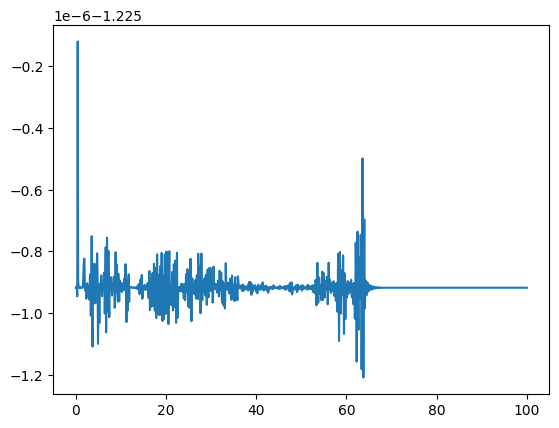

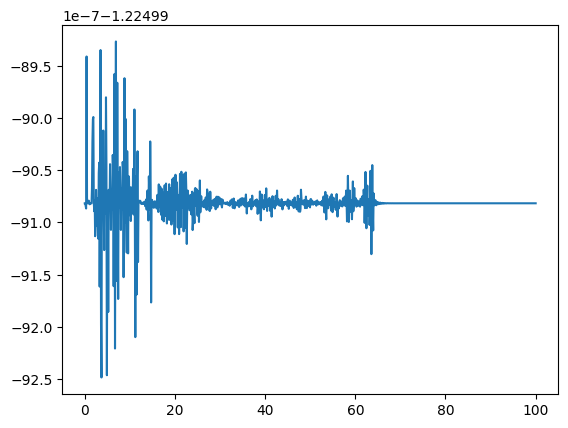

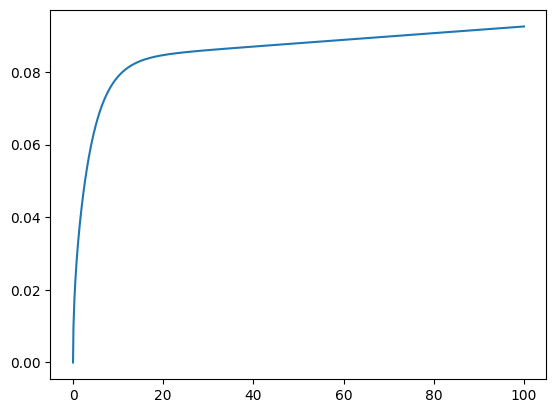

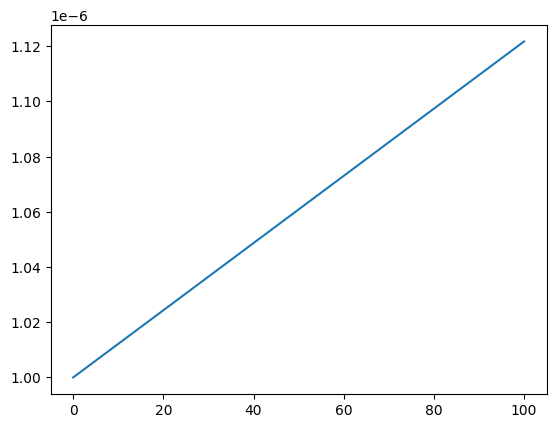

In [153]:
import matplotlib.pyplot as plt
plt.plot(sol.t, sol["J_sei"].entries[0])
plt.show()
plt.plot(sol.t, sol["J_int"].entries[10])
plt.show()
plt.plot(sol.t, sol["Potential in the SEI [V]"].entries[-1] -
         sol["Potential in the SEI [V]"].entries[0])
plt.show()
plt.plot(sol.t, sol["Thickness of SEI [m]"].entries)